Base directory: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design
Data file exists: True
Figure directory: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\3_Figures\Step1_Generative_Checks

Data shape after cleaning: (520000, 14)


,subject,trial,P,T,W,M,label,v,a,t0,z,RT,response,RT_ms
0,1,1,0.366880,-0.931297,0.804846,0,Other,0.225490,1.127363,0.2,1.774051,0.2,1,200.0
1,1,2,0.990155,-0.285340,0.671971,0,Other,0.228050,1.126696,0.2,1.775101,0.2,1,200.0
2,1,3,0.020037,0.633097,0.574705,1,Self,0.229255,1.124760,0.2,1.778157,0.2,1,200.0
3,1,4,-0.964234,0.097319,-0.932640,1,Self,0.228570,1.121988,0.2,1.782550,0.2,1,200.0
4,1,5,0.419720,0.229178,-0.245017,0,Other,0.229770,1.123978,0.2,1.779395,0.2,1,200.0


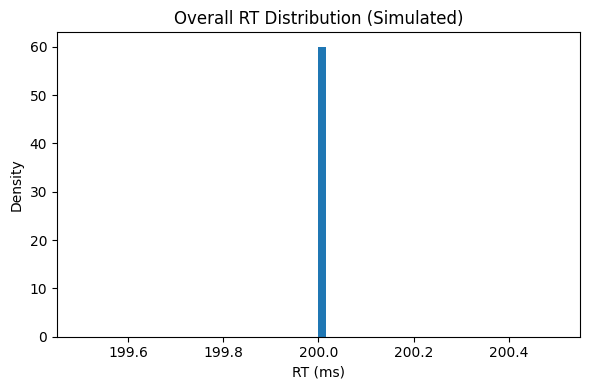

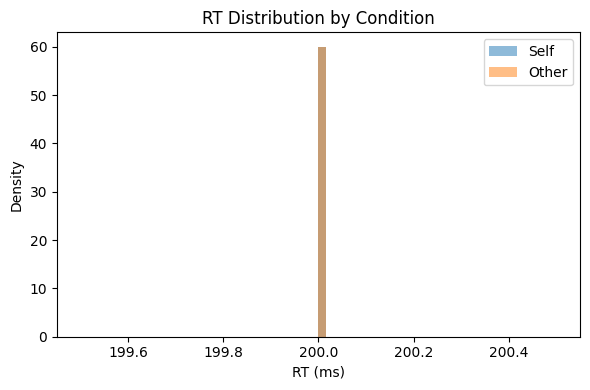


Subject-level RT means and SPE (first 5 subjects):


label,Other,Self,SPE_ms
subject,,,
1,200.0,200.0,0.0
2,200.0,200.0,0.0
3,200.0,200.0,0.0
4,200.0,200.0,0.0
5,200.0,200.0,0.0


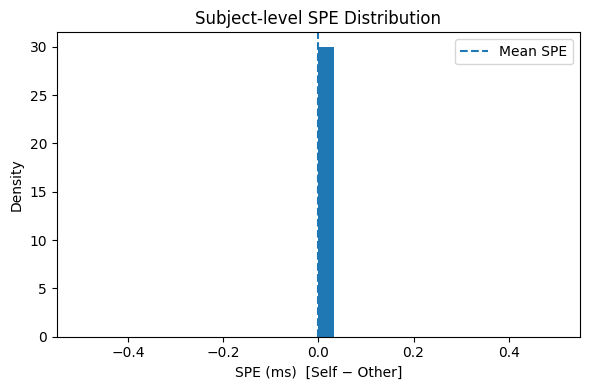

C:\Users\蔡振辛\AppData\Local\Temp\ipykernel_92712\1689819526.py:113: RuntimeWarning: invalid value encountered in scalar divide
  cohens_d = mean_spe / std_spe


===== SPE Summary =====
Mean SPE (ms): 0.00
SD SPE (ms): 0.00
Cohen's d (paired): nan
N subjects: 2000


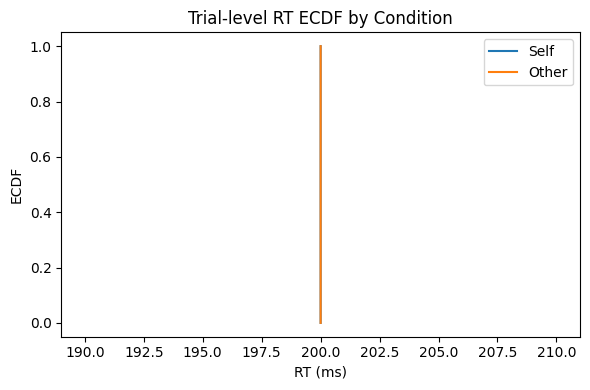


Saved figures to: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\3_Figures\Step1_Generative_Checks
Saved SPE summary to: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\3_Figures\Step1_Generative_Checks\SPE_summary.csv

Step 1 generative checks completed successfully.


In [ ]:
# ============================================================
# Step 1: Generative Model Checks (Distribution + SPE level)
# Environment: Jupyter / VSCode .ipynb
# Purpose:
#   - Distribution-level checks of RT
#   - Subject-level Self-Prioritization Effect (SPE)
#   - Trial-level ECDF visualization
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

# -------------------------
# 0. Path settings (for Jupyter / ipynb)
# -------------------------
# 当前 notebook 路径：Guassion-Process-Experiment-Design/1_Code/Python_for_pic/
# 项目根目录 = 向上两级
BASE_DIR = Path.cwd().parents[1]

DATA_PATH = BASE_DIR / "2_Data" / "Generate_Data" / "gp_ddm_simulation_v2-2000.csv"
FIG_DIR = BASE_DIR / "3_Figures" / "Step1_Generative_Checks"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Base directory:", BASE_DIR)
print("Data file exists:", DATA_PATH.exists())
print("Figure directory:", FIG_DIR)

# -------------------------
# 1. Load data
# -------------------------
df = pd.read_csv(DATA_PATH)

# RT: seconds -> milliseconds
df["RT_ms"] = df["RT"] * 1000

# keep valid responses only
df = df[df["response"].isin([0, 1])].copy()

print("\nData shape after cleaning:", df.shape)
display(df.head())

# -------------------------
# 2. Distribution-level checks
# -------------------------

# 2.1 Overall RT distribution
plt.figure(figsize=(6, 4))
plt.hist(df["RT_ms"], bins=60, density=True)
plt.xlabel("RT (ms)")
plt.ylabel("Density")
plt.title("Overall RT Distribution (Simulated)")
plt.tight_layout()
plt.savefig(FIG_DIR / "RT_distribution_overall.png", dpi=300)
plt.show()

# 2.2 RT distribution by condition
plt.figure(figsize=(6, 4))
for label in ["Self", "Other"]:
    subset = df[df["label"] == label]
    plt.hist(
        subset["RT_ms"],
        bins=60,
        density=True,
        alpha=0.5,
        label=label
    )

plt.xlabel("RT (ms)")
plt.ylabel("Density")
plt.title("RT Distribution by Condition")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "RT_distribution_by_condition.png", dpi=300)
plt.show()

# -------------------------
# 3. Subject-level SPE analysis
# -------------------------

# 3.1 Subject-level mean RT
subj_means = (
    df.groupby(["subject", "label"])["RT_ms"]
    .mean()
    .reset_index()
    .pivot(index="subject", columns="label", values="RT_ms")
    .dropna()
)

# SPE = Self - Other
subj_means["SPE_ms"] = subj_means["Self"] - subj_means["Other"]

print("\nSubject-level RT means and SPE (first 5 subjects):")
display(subj_means.head())

# 3.2 SPE distribution
plt.figure(figsize=(6, 4))
plt.hist(subj_means["SPE_ms"], bins=30, density=True)
plt.axvline(subj_means["SPE_ms"].mean(), linestyle="--", label="Mean SPE")
plt.xlabel("SPE (ms)  [Self − Other]")
plt.ylabel("Density")
plt.title("Subject-level SPE Distribution")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "SPE_distribution_subject_level.png", dpi=300)
plt.show()

# 3.3 Effect size: Cohen's d (paired)
mean_spe = subj_means["SPE_ms"].mean()
std_spe = subj_means["SPE_ms"].std(ddof=1)
cohens_d = mean_spe / std_spe

print("===== SPE Summary =====")
print(f"Mean SPE (ms): {mean_spe:.2f}")
print(f"SD SPE (ms): {std_spe:.2f}")
print(f"Cohen's d (paired): {cohens_d:.3f}")
print(f"N subjects: {subj_means.shape[0]}")

# -------------------------
# 4. Trial-level ECDF (descriptive only)
# -------------------------
plt.figure(figsize=(6, 4))

for label in ["Self", "Other"]:
    subset = df[df["label"] == label]["RT_ms"].values
    sorted_rt = np.sort(subset)
    ecdf = np.arange(1, len(sorted_rt) + 1) / len(sorted_rt)
    plt.plot(sorted_rt, ecdf, label=label)

plt.xlabel("RT (ms)")
plt.ylabel("ECDF")
plt.title("Trial-level RT ECDF by Condition")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "RT_ECDF_trial_level.png", dpi=300)
plt.show()

# -------------------------
# 5. Save numerical summary
# -------------------------
summary = pd.DataFrame({
    "Mean_SPE_ms": [mean_spe],
    "SD_SPE_ms": [std_spe],
    "Cohens_d": [cohens_d],
    "N_subjects": [subj_means.shape[0]]
})

summary_path = FIG_DIR / "SPE_summary.csv"
summary.to_csv(summary_path, index=False)

print("\nSaved figures to:", FIG_DIR)
print("Saved SPE summary to:", summary_path)
print("\nStep 1 generative checks completed successfully.")
